# TakeMeter — Fine-Tuning Starter Notebook
### AI201 · Project 3

This notebook walks you through fine-tuning a text classifier on your annotated dataset and comparing it to a zero-shot baseline.

**What this notebook does for you (infrastructure):**
- Tokenizes your dataset and prepares it for training
- Runs the fine-tuning pipeline with DistilBERT
- Computes evaluation metrics and generates a confusion matrix
- Runs the Groq baseline and compares both models

**What you do (the actual work):**
- Collect and annotate your 200+ examples (done before opening this notebook)
- Define your label map and upload your CSV
- Write your Groq classification prompt using your label definitions
- Analyze the output and write your evaluation report

---
**Before you start:** Make sure you are using a T4 GPU runtime.  
Go to **Runtime → Change runtime type → T4 GPU**, then click Save.

In [1]:
# Install any dependencies not pre-installed on Colab
!pip install -q groq python-dotenv
print("✅ Dependencies ready")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 13.5 MB/s eta 0:00:00
✅ Dependencies ready


In [2]:
!git clone https://github.com/ChariPramod/TakeMeter.git

Cloning into 'TakeMeter'...
remote: Enumerating objects: 75, done.
remote: Counting objects: 100% (75/75), done.
remote: Compressing objects: 100% (35/35), done.
remote: Total 75 (delta 41), reused 69 (delta 38), pack-reused 0 (from 0)
Receiving objects: 100% (75/75), 261.31 KiB | 1.35 MiB/s, done.
Resolving deltas: 100% (41/41), done.


In [3]:
import pandas as pd

# Load the dataset directly from the cloned repo
df = pd.read_csv('/content/TakeMeter/data/dataset.csv')

In [4]:
import pandas as pd
import numpy as np
import json
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from datasets import Dataset
import warnings
warnings.filterwarnings("ignore")

print("✅ Imports complete")
print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

✅ Imports complete
PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


---
## Section 1: Load Your Dataset

Upload your labeled CSV and define your label map.  
Your CSV must have at least two columns: `text` (the post/comment) and `label` (your string label).

In [5]:
# ── Label map for this project (r/wallstreetbets, 4 labels) ────────────────
# Keys are the EXACT string labels in your CSV's `label` column; values are
# contiguous integers 0..N-1. This MUST match planning.md §3/§10,
# scripts/validate_dataset.py (LABEL_MAP), and the README taxonomy table.
# ────────────────────────────────────────────────────────────────────────

LABEL_MAP = {
    "trade_analysis": 0,
    "market_reaction_or_hype": 1,
    "meme_or_shitpost": 2,
    "community_meta_or_news": 3,
}

ID_TO_LABEL = {v: k for k, v in LABEL_MAP.items()}
NUM_LABELS = len(LABEL_MAP)
print(f"Labels: {LABEL_MAP}")
print(f"Number of labels: {NUM_LABELS}")

Labels: {'trade_analysis': 0, 'market_reaction_or_hype': 1, 'meme_or_shitpost': 2, 'community_meta_or_news': 3}
Number of labels: 4


In [6]:
# Upload your CSV from your computer
from google.colab import files
print("Select your labeled dataset CSV file...")
uploaded = files.upload()
CSV_PATH = list(uploaded.keys())[0]
print(f"Uploaded: {CSV_PATH}")

Select your labeled dataset CSV file...


Saving dataset.csv to dataset.csv
Uploaded: dataset.csv


In [7]:
# Load and validate your dataset
df = pd.read_csv(CSV_PATH)

# ── TODO (if needed) ──────────────────────────────────────────────────────
# If your CSV uses different column names, rename them here.
# Example: df = df.rename(columns={"post": "text", "category": "label"})
# ── END TODO ──────────────────────────────────────────────────────────────

print(f"Columns: {df.columns.tolist()}")
print(f"Total examples: {len(df)}")
print()
print("Label distribution:")
print(df["label"].value_counts())

# Validate all labels are in LABEL_MAP
unknown = set(df["label"].unique()) - set(LABEL_MAP.keys())
if unknown:
    print(f"\n⚠️  Labels in CSV not found in LABEL_MAP: {unknown}")
    print("Update your LABEL_MAP above to include all labels.")
else:
    print("\n✅ All labels match your LABEL_MAP")

# Convert string labels to integers
df["label_id"] = df["label"].map(LABEL_MAP)
df = df.dropna(subset=["label_id"])
df["label_id"] = df["label_id"].astype(int)

Columns: ['text', 'label', 'id', 'score', 'comms_num', 'timestamp', 'url']
Total examples: 437

Label distribution:
label
market_reaction_or_hype    163
trade_analysis             113
community_meta_or_news     108
meme_or_shitpost            53
Name: count, dtype: int64

✅ All labels match your LABEL_MAP


---
## Section 2: Prepare Data for Training

Splits your dataset into train / validation / test sets and tokenizes the text.

In [8]:
# Train / val / test split — 70% / 15% / 15%
# Stratified so each split has roughly the same label distribution.
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=42, stratify=df["label_id"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=temp_df["label_id"]
)

print(f"Train: {len(train_df)} examples")
print(f"Validation: {len(val_df)} examples")
print(f"Test: {len(test_df)} examples")
print()
print("Train label distribution:")
print(train_df["label"].value_counts())
print()
print("Test label distribution:")
print(test_df["label"].value_counts())

# Reset indices (needed for clean HuggingFace Dataset conversion)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

Train: 305 examples
Validation: 66 examples
Test: 66 examples

Train label distribution:
label
market_reaction_or_hype    114
trade_analysis              79
community_meta_or_news      75
meme_or_shitpost            37
Name: count, dtype: int64

Test label distribution:
label
market_reaction_or_hype    25
trade_analysis             17
community_meta_or_news     16
meme_or_shitpost            8
Name: count, dtype: int64


In [9]:
# Load tokenizer and tokenize all splits
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(examples):
    return tokenizer(examples["text"], truncation=True, max_length=256)

def make_dataset(df_split):
    ds = Dataset.from_pandas(
        df_split[["text", "label_id"]].rename(columns={"label_id": "labels"})
    )
    return ds.map(tokenize, batched=True)

train_dataset = make_dataset(train_df)
val_dataset   = make_dataset(val_df)
test_dataset  = make_dataset(test_df)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print("✅ Tokenization complete")
print(f"Sample keys: {list(train_dataset[0].keys())}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/305 [00:00<?, ? examples/s]

Map:   0%|          | 0/66 [00:00<?, ? examples/s]

Map:   0%|          | 0/66 [00:00<?, ? examples/s]

✅ Tokenization complete
Sample keys: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask']


---
## Section 3: Fine-Tune Your Model

Loads `distilbert-base-uncased` with a classification head and fine-tunes it on your training data.  
Training runs for 3 epochs and takes **5–15 minutes** on a T4 GPU.

> **Hyperparameter note:** The defaults below work well for datasets of 100–500 examples.  
> If you change any values, note what you changed and why in your README.

In [10]:
# Load DistilBERT with a classification head
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=ID_TO_LABEL,
    label2id=LABEL_MAP,
)
print(f"✅ Model loaded: {MODEL_NAME}")
print(f"Output labels: {NUM_LABELS}")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model loaded: distilbert-base-uncased
Output labels: 4


In [ ]:
from sklearn.metrics import f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    # Track BOTH: accuracy for reference, macro-F1 as the selection metric.
    # Macro-F1 weights all 4 classes equally, so the model can't "win" by
    # ignoring the minority classes (meme_or_shitpost, community_meta_or_news).
    return {
        "accuracy": accuracy_score(labels, predictions),
        "macro_f1": f1_score(labels, predictions, average="macro"),
    }

In [ ]:
# ── Hyperparameters (tuned to fix minority-class collapse) ─────────────────
# The first run (3 epochs, unweighted loss, best-by-accuracy) collapsed: the
# model ignored the two smaller classes (meme_or_shitpost, community_meta_or_news
# both at F1 0.00) and lost to the baseline. Three changes address that:
#
#   1. CLASS-WEIGHTED LOSS — weight each class by inverse frequency so errors on
#      the rare classes are penalized proportionally. This is the main fix.
#   2. num_train_epochs 3 -> 6 — the small set (305 train) needs more passes to
#      learn the minority classes; load_best_model_at_end guards overfitting.
#   3. metric_for_best_model "accuracy" -> "macro_f1" — accuracy rewards
#      predicting the majority class; macro-F1 forces all classes to matter.
#
# Document these three changes (and why) in the README "Model + training".
# ─────────────────────────────────────────────────────────────────────────
import torch.nn as nn

# Inverse-frequency class weights from the TRAINING split only (no test leakage).
class_counts = train_df["label_id"].value_counts().sort_index()
weights = len(train_df) / (NUM_LABELS * class_counts.values)
class_weights = torch.tensor(weights, dtype=torch.float)
print("Class weights (by label id):",
      {ID_TO_LABEL[i]: round(float(w), 2) for i, w in enumerate(class_weights)})


class WeightedTrainer(Trainer):
    """Trainer that applies class-weighted cross-entropy in compute_loss."""
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = nn.CrossEntropyLoss(
            weight=class_weights.to(logits.device)
        )
        loss = loss_fct(logits.view(-1, NUM_LABELS), labels.view(-1))
        return (loss, outputs) if return_outputs else loss


training_args = TrainingArguments(
    output_dir="./takemeter-model",
    num_train_epochs=6,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    logging_steps=10,
    report_to="none",
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Starting fine-tuning... (5–15 minutes on T4 GPU)")
trainer.train()
print("\n✅ Fine-tuning complete")

---
## Section 4: Evaluate Fine-Tuned Model on Test Set

Runs inference on your locked test set and generates metrics and a confusion matrix.  
These numbers go directly into your evaluation report.

In [13]:
# Run inference on the test set
print("Running inference on test set...")
ft_output = trainer.predict(test_dataset)
ft_pred_ids = np.argmax(ft_output.predictions, axis=-1)
ft_true_ids = ft_output.label_ids

ft_probs = torch.nn.functional.softmax(
    torch.tensor(ft_output.predictions), dim=-1
).numpy()

# Overall accuracy
ft_accuracy = accuracy_score(ft_true_ids, ft_pred_ids)
print(f"\n🎯 Fine-tuned model accuracy: {ft_accuracy:.3f}")

# Per-class metrics
label_names = [ID_TO_LABEL[i] for i in range(NUM_LABELS)]
print("\nPer-class metrics (fine-tuned model):")
print(classification_report(ft_true_ids, ft_pred_ids, target_names=label_names, zero_division=0))

Running inference on test set...



🎯 Fine-tuned model accuracy: 0.561

Per-class metrics (fine-tuned model):
                         precision    recall  f1-score   support

         trade_analysis       0.61      1.00      0.76        17
market_reaction_or_hype       0.53      0.80      0.63        25
       meme_or_shitpost       0.00      0.00      0.00         8
 community_meta_or_news       0.00      0.00      0.00        16

               accuracy                           0.56        66
              macro avg       0.28      0.45      0.35        66
           weighted avg       0.36      0.56      0.44        66



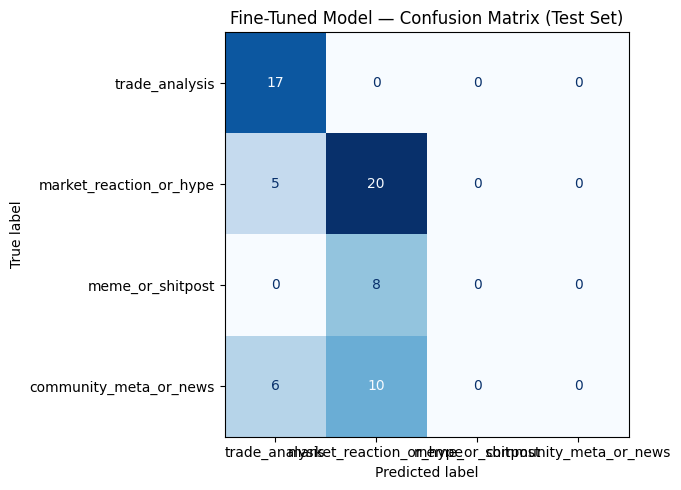

✅ Saved: confusion_matrix.png  →  commit this to your repo and include in README


In [14]:
# Confusion matrix
cm = confusion_matrix(ft_true_ids, ft_pred_ids)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Fine-Tuned Model — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("✅ Saved: confusion_matrix.png  →  commit this to your repo and include in README")

In [15]:
# Print wrong predictions for your error analysis
# Review these carefully — pick 3 to analyze in depth in your README.

wrong_idx = np.where(ft_pred_ids != ft_true_ids)[0]
print(f"Wrong predictions: {len(wrong_idx)} / {len(ft_true_ids)}\n")

for i, idx in enumerate(wrong_idx[:15]):
    text = test_df.iloc[idx]["text"]
    true_label = ID_TO_LABEL[ft_true_ids[idx]]
    pred_label = ID_TO_LABEL[ft_pred_ids[idx]]
    confidence = ft_probs[idx][ft_pred_ids[idx]]
    print(f"--- #{i+1} ---")
    print(f"Text:      {text[:200]}{'...' if len(text) > 200 else ''}")
    print(f"True:      {true_label}")
    print(f"Predicted: {pred_label}  (confidence: {confidence:.2f})")
    print()

Wrong predictions: 29 / 66

--- #1 ---
Text:      Gamestonks fallout? Hey I am very new to this sub but I can tell I love the vibe here. I am fairly new to stocks and only do long term trading so I may be wrong when it comes to this but I have a ques...
True:      community_meta_or_news
Predicted: trade_analysis  (confidence: 0.39)

--- #2 ---
Text:      Monkey get banana, other monkey take bite. Monkey mad... monkey buy more banana. Monkey grip strong, monkey fuse carbon molecule. Monkey no let go💎👊
True:      meme_or_shitpost
Predicted: market_reaction_or_hype  (confidence: 0.38)

--- #3 ---
Text:      Can we agree that Fidelity’s App is hot garbage Hello fellow autists 🦍. I come before you today to enlist your help in submitting a formal request to Fidelity to fix that God awful thing they call an ...
True:      community_meta_or_news
Predicted: trade_analysis  (confidence: 0.40)

--- #4 ---
Text:      Didi app suspended in China over data protection
True:      community_meta_or_new

---
## Section 5: Baseline Classifier (Groq)

Runs your zero-shot baseline using `llama-3.3-70b-versatile`.  
You need to write the classification prompt using your label definitions.

In [18]:
from groq import Groq

# ── TODO: Add your Groq API key ───────────────────────────────────────────
# Recommended: use Colab Secrets so your key is never visible in the notebook.
#   1. Click the 🔑 icon in the left sidebar ("Secrets")
#   2. Add a secret named GROQ_API_KEY with your key as the value
#   3. Enable notebook access for the secret
#
# Then uncomment Option A below (and delete Option B).
#
# Option A — Colab Secrets (recommended):
from google.colab import userdata
GROQ_API_KEY = userdata.get("GROQ_API_KEY")
#
# Option B — paste directly (do not commit to GitHub):
#GROQ_API_KEY = "your_groq_api_key_here"

assert GROQ_API_KEY, (
    "GROQ_API_KEY not set — add it in the Colab Secrets panel (🔑, left "
    "sidebar) and enable notebook access for this notebook, or use Option B above."
)

client = Groq(api_key=GROQ_API_KEY)
print("✅ Groq client initialized")

✅ Groq client initialized


In [19]:
# ── Classification prompt (zero-shot baseline) ────────────────────────────
# Definitions and examples below are transcribed from the student's own
# planning.md §3 (label design). Label NAMES must stay exactly as listed so the
# parser in classify_with_groq() matches. Edit wording here if you refine §3.
# ─────────────────────────────────────────────────────────────────────────

SYSTEM_PROMPT = """
You are classifying posts from the r/wallstreetbets subreddit, where users
discuss stock and option trading. Assign each post to exactly ONE of the
following four categories, based on the author's primary purpose.

trade_analysis: The post's main purpose is to explain, justify, or evaluate a
stock, option, market move, or trading strategy using reasoning, evidence,
numbers, screenshots, ticker discussion, or a clear thesis.
Example: "Why I think GME is undervalued: short interest is still high, here are
the catalysts and the price action, and this is the position I'm taking."

market_reaction_or_hype: The post's main purpose is to react emotionally to
market movement, hype a ticker, celebrate gains, panic about losses, or
encourage buying/selling without substantial analysis.
Example: "GME TO THE MOON, HOLD THE LINE 🚀🚀"

meme_or_shitpost: The post's main purpose is humor, sarcasm, community slang,
absurdity, or entertainment rather than serious trading discussion.
Example: "My portfolio is a burning dumpster and I am the raccoon inside it."

community_meta_or_news: The post's main purpose is to discuss the subreddit,
moderation, daily discussion threads, media attention, platform issues, rules,
or external news about WallStreetBets rather than a specific personal trade.
Example: "How has this sub changed since the news coverage after the GameStop
saga? Curious what longtime members think."

Decision rule for mixed posts: label by the author's primary purpose. If a post
makes a real trade thesis with reasoning, it is trade_analysis; if it mainly
pushes emotion or group action with little reasoning, it is
market_reaction_or_hype; if the joke format is the main point, it is
meme_or_shitpost.

Respond with ONLY the label name.
Do not explain your reasoning.

Valid labels:
trade_analysis
market_reaction_or_hype
meme_or_shitpost
community_meta_or_news
"""

print("Prompt length:", len(SYSTEM_PROMPT), "characters")

Prompt length: 1879 characters


In [20]:
def classify_with_groq(text):
    """Classify a single post. Returns a label string or None if unparseable."""
    try:
        response = client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": f"Classify this post:\n\n{text}"},
            ],
            temperature=0,
            max_tokens=20,
        )
        raw = response.choices[0].message.content.strip().lower()
        # Match the model's output to a label. Check longest labels first so a
        # label that is a substring of another (e.g. "recommendation" vs.
        # "strong_recommendation") can't be matched by mistake.
        for label in sorted(LABEL_MAP, key=len, reverse=True):
            if raw == label or label in raw:
                return label
        return None  # model output didn't match any known label
    except Exception as e:
        print(f"API error: {e}")
        return None


# Run baseline on test set
print(f"Running baseline on {len(test_df)} examples...")
print("(May take a few minutes — 0.1s delay between requests to respect free-tier limits)\n")

baseline_preds = []
for i, (_, row) in enumerate(test_df.iterrows()):
    pred = classify_with_groq(row["text"])
    baseline_preds.append(pred)
    if (i + 1) % 10 == 0:
        print(f"  {i+1}/{len(test_df)} complete...")
    time.sleep(0.1)

none_count = baseline_preds.count(None)
if none_count > 0:
    print(f"\n⚠️  {none_count} responses could not be parsed.")
    print("Review your prompt — the model may not be outputting clean label names.")

Running baseline on 66 examples...
(May take a few minutes — 0.1s delay between requests to respect free-tier limits)

  10/66 complete...
  20/66 complete...
  30/66 complete...
  40/66 complete...
  50/66 complete...
  60/66 complete...


In [21]:
# Baseline metrics (exclude unparseable responses)
valid = [(p, t) for p, t in zip(baseline_preds, test_df["label_id"])
         if p is not None]
bl_pred_ids = [LABEL_MAP[p] for p, _ in valid]
bl_true_ids = [t for _, t in valid]

bl_accuracy = accuracy_score(bl_true_ids, bl_pred_ids)
print(f"🎯 Baseline accuracy: {bl_accuracy:.3f}  "
      f"(evaluated on {len(valid)}/{len(test_df)} parseable responses)")
print()
label_names = [ID_TO_LABEL[i] for i in range(NUM_LABELS)]
print("Per-class metrics (baseline):")
print(classification_report(bl_true_ids, bl_pred_ids, target_names=label_names, zero_division=0))

🎯 Baseline accuracy: 0.818  (evaluated on 66/66 parseable responses)

Per-class metrics (baseline):
                         precision    recall  f1-score   support

         trade_analysis       0.80      0.94      0.86        17
market_reaction_or_hype       0.80      0.96      0.87        25
       meme_or_shitpost       0.86      0.75      0.80         8
 community_meta_or_news       0.89      0.50      0.64        16

               accuracy                           0.82        66
              macro avg       0.84      0.79      0.79        66
           weighted avg       0.83      0.82      0.81        66



---
## Section 6: Compare Results and Export

Side-by-side comparison of both models.  
Download the output files and commit them to your GitHub repo.

In [22]:
print("=" * 50)
print("RESULTS COMPARISON")
print("=" * 50)
print(f"{'Model':<35} {'Accuracy':>8}")
print("-" * 45)
print(f"{'Zero-shot baseline (Groq)':<35} {bl_accuracy:>8.3f}")
print(f"{'Fine-tuned DistilBERT':<35} {ft_accuracy:>8.3f}")
print("-" * 45)
delta = ft_accuracy - bl_accuracy
direction = "improvement" if delta >= 0 else "regression"
print(f"\nFine-tuning {direction}: {abs(delta):.3f}")
print()
print("Use these numbers in your README evaluation report.")

RESULTS COMPARISON
Model                               Accuracy
---------------------------------------------
Zero-shot baseline (Groq)              0.818
Fine-tuned DistilBERT                  0.561
---------------------------------------------

Fine-tuning regression: 0.258

Use these numbers in your README evaluation report.


In [23]:
# Save results JSON — commit to your GitHub repo and reference in README
results = {
    "baseline_accuracy": round(bl_accuracy, 4),
    "finetuned_accuracy": round(ft_accuracy, 4),
    "improvement": round(ft_accuracy - bl_accuracy, 4),
    "test_set_size": len(test_df),
    "label_map": LABEL_MAP,
    "model": MODEL_NAME,
}
with open("evaluation_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("✅ Files ready to download:")
print("   evaluation_results.json  — metrics for your README")
print("   confusion_matrix.png     — include in your README")
print()
print("Download via: Files panel (📁) on the left → right-click → Download")

✅ Files ready to download:
   evaluation_results.json  — metrics for your README
   confusion_matrix.png     — include in your README

Download via: Files panel (📁) on the left → right-click → Download
